# LMB vs. Alternatives: A First Comparison
### For: *Federated MARL with LMB for Spoofed-Device IoT Defense*

This notebook implements three RFS-family filters side by side, on the same simulated world used in
`lmb_stage0_sanity_check.ipynb`, so you can compare them directly:

1. **LMB** (Labeled Multi-Bernoulli) — the filter from the first notebook. Maintains a persistent, labeled
   track per device.
2. **GM-PHD** (Gaussian-Mixture Probability Hypothesis Density) — simpler and cheaper. Propagates an
   unlabeled intensity function. Gives you "how many, roughly where", but **not** which specific device.
3. **PMB** (Poisson Multi-Bernoulli) — a single-hypothesis, computationally cheap approximation of the full
   **PMBM** (Poisson Multi-Bernoulli Mixture) filter. PMBM is reported in the tracking literature as more
   accurate than LMB/GLMB because it is an exact conjugate prior, while LMB is an approximation of it. This
   PMB implementation keeps that idea (a Poisson pool for undetected/new devices, feeding a multi-Bernoulli
   set of confirmed tracks) but drops the full multi-hypothesis bookkeeping for simplicity.

**Not implemented here:** belief-propagation multi-target tracking (BP-MTT). It isn't a competing state
model — it's a different, more scalable way to solve the *association* step underneath any of the three
filters above, via message passing instead of combinatorial search. It is described in the tracking
literature as well suited to real-time operation on resource-limited devices, which is a good match for
large IoT fleets, and it directly addresses the scalability weakness already flagged in the roadmap for
LMB/GLMB. It is left out here because implementing a factor-graph message-passing filter from scratch is a
substantially bigger undertaking than the three filters above. If this direction looks promising after the
comparison below, that is the natural next build. Key references: Meyer et al., "Message Passing Algorithms
for Scalable Multitarget Tracking," *Proc. IEEE*, 2018; Meyer & Williams, "A Fast Labeled Multi-Bernoulli
Filter Using Belief Propagation" (BP-LMB — speeds up LMB specifically, rather than replacing it).

**Scope reminder:** everything below runs on the same toy synthetic simulator as the first notebook. It is
useful for comparing the *mechanics and cardinality behavior* of these filters cheaply, but it does not
validate any of them for real IoT identity ambiguity. That is still the job of the roadmap's Stage 1
CICIoT2023 experiment.

## 1. Setup (same simulator as the first notebook)

In [1]:
import numpy as np
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt

T = 60
N_DEVICES = 8
P_SURVIVE = 0.97
P_DETECT = 0.9
CLUTTER_RATE = 1
BIRTH_PROB = 0.03
MEAS_NOISE_STD = 0.3
PROCESS_NOISE_STD = 0.15
STATE_RANGE = (0, 20)
BIRTH_VAR = 1.0
GATE_NLL = 9.0
CLUTTER_INTENSITY = CLUTTER_RATE / (STATE_RANGE[1] - STATE_RANGE[0])


class TrueDevice:
    def __init__(self, label):
        self.label = label
        self.compromised = False
        self.state = 0.0

    def step(self):
        if self.compromised:
            if np.random.rand() > P_SURVIVE:
                self.compromised, self.state = False, 0.0
            else:
                self.state = max(0.0, self.state + np.random.normal(0.3, PROCESS_NOISE_STD))
        else:
            if np.random.rand() < BIRTH_PROB:
                self.compromised, self.state = True, np.random.uniform(1, 3)
        return self.compromised, self.state


def simulate(id_corruption=0.0, hub_ids=(100, 101)):
    devices = [TrueDevice(i) for i in range(N_DEVICES)]
    true_counts, meas_hist = [], []
    for _ in range(T):
        count, meas_t = 0, []
        for d in devices:
            comp, state = d.step()
            if comp:
                count += 1
                if np.random.rand() < P_DETECT:
                    z = state + np.random.normal(0, MEAS_NOISE_STD)
                    id_hint = d.label
                    if np.random.rand() < id_corruption:
                        id_hint = hub_ids[np.random.randint(len(hub_ids))]
                    meas_t.append({'id_hint': id_hint, 'z': z})
        for _ in range(np.random.poisson(CLUTTER_RATE)):
            meas_t.append({'id_hint': None, 'z': np.random.uniform(*STATE_RANGE)})
        true_counts.append(count)
        meas_hist.append(meas_t)
    return true_counts, meas_hist


def gL(z, mean, var):
    return np.exp(-0.5 * (z - mean) ** 2 / var) / np.sqrt(2 * np.pi * var)


def naive_distinct_id_count(meas_hist):
    return [len(set(m['id_hint'] for m in meas if m['id_hint'] is not None)) for meas in meas_hist]

## 2. LMB filter (from the first notebook, condensed)

In [2]:
class LMBFilter:
    def __init__(self, birth_labels=range(N_DEVICES)):
        self.birth_labels = list(birth_labels)
        self.components = {}

    def predict(self):
        for c in self.components.values():
            c['r'] *= P_SURVIVE
            c['var'] += PROCESS_NOISE_STD ** 2
        for lbl in self.birth_labels:
            if lbl not in self.components:
                self.components[lbl] = {'r': 0.02, 'mean': 2.0, 'var': BIRTH_VAR}

    def update(self, meas):
        labels = list(self.components.keys())
        zs = [m['z'] for m in meas]
        assigned = {l: None for l in labels}
        if labels and zs:
            cost = np.full((len(labels), len(zs)), 1e6)
            for i, l in enumerate(labels):
                c = self.components[l]
                S = c['var'] + MEAS_NOISE_STD ** 2
                for j, z in enumerate(zs):
                    nll = 0.5 * (z - c['mean']) ** 2 / S
                    cost[i, j] = nll if nll < GATE_NLL else 1e6
            row, col = linear_sum_assignment(cost)
            for i, j in zip(row, col):
                if cost[i, j] < 1e6:
                    assigned[labels[i]] = zs[j]
        for l in labels:
            c = self.components[l]
            r, m, v = c['r'], c['mean'], c['var']
            S = v + MEAS_NOISE_STD ** 2
            z = assigned[l]
            if z is not None:
                psi = gL(z, m, S) / CLUTTER_INTENSITY
                num, den = r * P_DETECT * psi, 1 - r * P_DETECT + r * P_DETECT * psi
                r2 = num / den if den > 1e-9 else 0.0
                K = v / S
                m2, v2 = m + K * (z - m), (1 - K) * v
            else:
                num, den = r * (1 - P_DETECT), 1 - r * P_DETECT
                r2 = num / den if den > 1e-9 else 0.0
                m2, v2 = m, v
            c['r'], c['mean'], c['var'] = float(np.clip(r2, 0, 1)), float(m2), float(max(v2, 1e-3))
        self.components = {l: c for l, c in self.components.items() if c['r'] > 1e-3}

    def cardinality(self):
        return sum(c['r'] for c in self.components.values())

## 3. GM-PHD filter

Propagates a Gaussian-mixture **intensity** rather than per-object tracks. Update creates one term per
existing component for a missed detection, plus one term per (component, measurement) pair for a
detection, each reweighted by how well it explains that measurement versus clutter. Components are then
pruned (drop near-zero weight) and merged (nearby components combined) to keep the mixture small.

**Key limitation for your use case:** this filter estimates *how many devices are compromised*, but not
persistent *which-device* identity across time — there is no label to say "this is the same device I was
tracking 10 steps ago." If per-device identity matters (and for isolating a specific device, it does),
that's a real limitation, not just a simplification.

In [3]:
class PHDFilter:
    def __init__(self, birth_weight=N_DEVICES * BIRTH_PROB, birth_mean=2.0, birth_var=BIRTH_VAR,
                 prune_w=1e-3, merge_dist=1.0, max_components=50):
        self.comps = []
        self.birth_weight, self.birth_mean, self.birth_var = birth_weight, birth_mean, birth_var
        self.prune_w, self.merge_dist, self.max_components = prune_w, merge_dist, max_components

    def predict(self):
        for c in self.comps:
            c['w'] *= P_SURVIVE
            c['var'] += PROCESS_NOISE_STD ** 2
        self.comps.append({'w': self.birth_weight, 'mean': self.birth_mean, 'var': self.birth_var})

    def update(self, meas):
        zs = [m['z'] for m in meas]
        new_comps = [{'w': c['w'] * (1 - P_DETECT), 'mean': c['mean'], 'var': c['var']} for c in self.comps]
        for z in zs:
            terms = []
            for c in self.comps:
                S = c['var'] + MEAS_NOISE_STD ** 2
                K = c['var'] / S
                m2, v2 = c['mean'] + K * (z - c['mean']), (1 - K) * c['var']
                terms.append({'w': c['w'] * P_DETECT * gL(z, c['mean'], S), 'mean': m2, 'var': v2})
            denom = CLUTTER_INTENSITY + sum(t['w'] for t in terms)
            for t in terms:
                t['w'] = t['w'] / denom if denom > 1e-12 else 0.0
                new_comps.append(t)
        self.comps = new_comps
        self._prune_and_merge()

    def _prune_and_merge(self):
        comps = sorted([c for c in self.comps if c['w'] > self.prune_w], key=lambda c: -c['w'])
        merged, used = [], [False] * len(comps)
        for i in range(len(comps)):
            if used[i]:
                continue
            group = [comps[i]]
            used[i] = True
            for j in range(i + 1, len(comps)):
                if not used[j] and abs(comps[j]['mean'] - comps[i]['mean']) < self.merge_dist:
                    group.append(comps[j])
                    used[j] = True
            w_sum = sum(g['w'] for g in group)
            mean_m = sum(g['w'] * g['mean'] for g in group) / w_sum
            var_m = sum(g['w'] * (g['var'] + (g['mean'] - mean_m) ** 2) for g in group) / w_sum
            merged.append({'w': w_sum, 'mean': mean_m, 'var': var_m})
        self.comps = sorted(merged, key=lambda c: -c['w'])[:self.max_components]

    def cardinality(self):
        return sum(c['w'] for c in self.comps)

## 4. PMB filter (simplified PMBM approximation)

A Poisson pool represents devices that might exist but have never been individually confirmed (the
"undetected" population). A multi-Bernoulli set represents devices that have been detected at least once
and now have their own track. Each step: existing Bernoulli tracks are updated via nearest-neighbor (like
LMB); any leftover, unassigned measurement is checked against the Poisson pool, and if it's a much better
match than clutter, a **new** Bernoulli track is born from it.

This is the cheap, single-hypothesis **PMB** approximation of the full **PMBM** filter, not full PMBM (see
Xia, Granström, Svensson & Fatemi, *"Poisson Multi-Bernoulli Approximations for Multiple Extended Object
Filtering,"* arXiv:1801.01353, for the real thing and why it's cheaper than full PMBM while keeping most of
its behavior).

In [4]:
class PMBFilter:
    def __init__(self, birth_weight=N_DEVICES * BIRTH_PROB, birth_mean=2.0, birth_var=BIRTH_VAR):
        self.poisson = [{'w': birth_weight, 'mean': birth_mean, 'var': birth_var}]
        self.bernoulli = {}
        self.birth_weight, self.birth_mean, self.birth_var = birth_weight, birth_mean, birth_var
        self._next_id = 0

    def predict(self):
        for c in self.poisson:
            c['w'] *= P_SURVIVE
            c['var'] += PROCESS_NOISE_STD ** 2
        self.poisson.append({'w': self.birth_weight, 'mean': self.birth_mean, 'var': self.birth_var})
        for c in self.bernoulli.values():
            c['r'] *= P_SURVIVE
            c['var'] += PROCESS_NOISE_STD ** 2

    def update(self, meas):
        zs = [m['z'] for m in meas]
        used = [False] * len(zs)
        labels = list(self.bernoulli.keys())
        if labels and zs:
            cost = np.full((len(labels), len(zs)), 1e6)
            for i, l in enumerate(labels):
                c = self.bernoulli[l]
                S = c['var'] + MEAS_NOISE_STD ** 2
                for j, z in enumerate(zs):
                    nll = 0.5 * (z - c['mean']) ** 2 / S
                    cost[i, j] = nll if nll < GATE_NLL else 1e6
            row, col = linear_sum_assignment(cost)
            assigned = {l: None for l in labels}
            for i, j in zip(row, col):
                if cost[i, j] < 1e6:
                    assigned[labels[i]] = zs[j]
                    used[j] = True
            for l in labels:
                c = self.bernoulli[l]
                r, m, v = c['r'], c['mean'], c['var']
                S = v + MEAS_NOISE_STD ** 2
                z = assigned[l]
                if z is not None:
                    psi = gL(z, m, S) / CLUTTER_INTENSITY
                    num, den = r * P_DETECT * psi, 1 - r * P_DETECT + r * P_DETECT * psi
                    r2 = num / den if den > 1e-9 else 0.0
                    K = v / S
                    m2, v2 = m + K * (z - m), (1 - K) * v
                else:
                    num, den = r * (1 - P_DETECT), 1 - r * P_DETECT
                    r2 = num / den if den > 1e-9 else 0.0
                    m2, v2 = m, v
                c['r'], c['mean'], c['var'] = float(np.clip(r2, 0, 1)), float(m2), float(max(v2, 1e-3))
        for j, z in enumerate(zs):
            if used[j]:
                continue
            best, best_val = None, -1
            for c in self.poisson:
                S = c['var'] + MEAS_NOISE_STD ** 2
                val = c['w'] * P_DETECT * gL(z, c['mean'], S)
                if val > best_val:
                    best_val, best = val, (c, S)
            if best is None:
                continue
            c, S = best
            denom = best_val + CLUTTER_INTENSITY
            r_new = best_val / denom if denom > 1e-12 else 0.0
            if r_new > 0.05:  # weak evidence -> treat as clutter, don't spawn a track
                K = c['var'] / S
                m2, v2 = c['mean'] + K * (z - c['mean']), (1 - K) * c['var']
                self.bernoulli[self._next_id] = {'r': float(np.clip(r_new, 0, 1)), 'mean': float(m2), 'var': float(max(v2, 1e-3))}
                self._next_id += 1
        self.bernoulli = {l: c for l, c in self.bernoulli.items() if c['r'] > 1e-3}
        self.poisson = sorted(self.poisson, key=lambda c: -c['w'])[:10]

    def cardinality(self):
        return sum(c['r'] for c in self.bernoulli.values())

## 5. Run helper

In [5]:
def run(FilterClass, meas_hist):
    f = FilterClass()
    est = []
    for t in range(len(meas_hist)):
        f.predict()
        f.update(meas_hist[t])
        est.append(f.cardinality())
    return est

## 6. Clean-identity comparison (Stage 0-style)

  method    cardinality MAE
   naive               0.15
     LMB               1.44
     PHD               0.58
     PMB               0.79


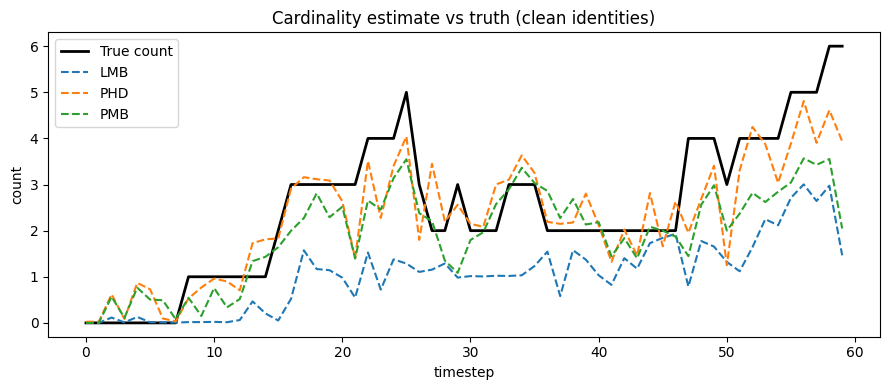

In [6]:
np.random.seed(42)
true_counts, meas_hist = simulate(id_corruption=0.0)

naive_est = naive_distinct_id_count(meas_hist)
lmb_est = run(LMBFilter, meas_hist)
phd_est = run(PHDFilter, meas_hist)
pmb_est = run(PMBFilter, meas_hist)

results = {'naive': naive_est, 'LMB': lmb_est, 'PHD': phd_est, 'PMB': pmb_est}
print(f"{'method':>8} {'cardinality MAE':>18}")
for name, est in results.items():
    mae = np.mean(np.abs(np.array(est) - np.array(true_counts)))
    print(f"{name:>8} {mae:>18.2f}")

plt.figure(figsize=(9, 4))
plt.plot(true_counts, label="True count", linewidth=2, color='black')
for name, est in results.items():
    if name != 'naive':
        plt.plot(est, linestyle='--', label=name)
plt.xlabel("timestep"); plt.ylabel("count"); plt.legend()
plt.title("Cardinality estimate vs truth (clean identities)")
plt.tight_layout(); plt.show()

## 7. Identity-corruption comparison, averaged over seeds

Same idea as the first notebook's Section 6, now across all four methods. Naive should degrade as
corruption increases (it trusts `id_hint`). LMB, PHD and PMB should all stay roughly flat, since none of
their `update()` methods read `id_hint` — they associate purely on the numeric measurement value.

corruption    naive      LMB      PHD      PMB
       0.0     0.31     2.15     0.84     1.58
       0.3     0.41     1.81     0.73     1.28
       0.6     0.74     1.71     0.74     1.13
       0.9     1.22     1.90     0.84     1.40


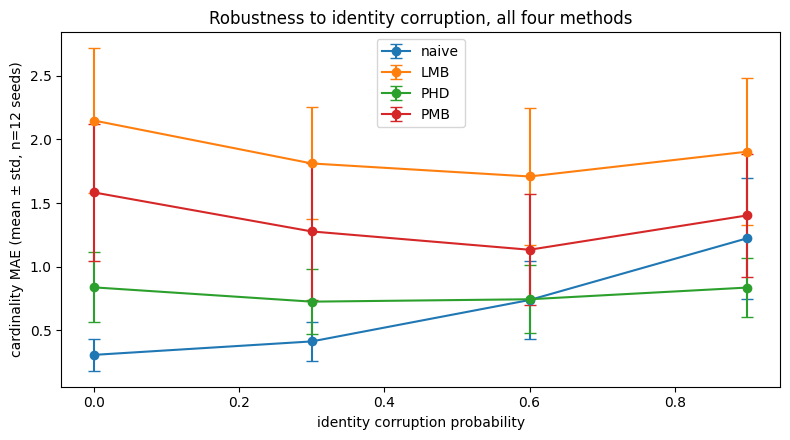

In [7]:
n_seeds = 12
corruption_levels = [0.0, 0.3, 0.6, 0.9]
results_c = {name: {p: [] for p in corruption_levels} for name in ['naive', 'LMB', 'PHD', 'PMB']}

for seed in range(n_seeds):
    np.random.seed(seed)
    for p in corruption_levels:
        tc, mh = simulate(id_corruption=p)
        ests = {'naive': naive_distinct_id_count(mh), 'LMB': run(LMBFilter, mh),
                'PHD': run(PHDFilter, mh), 'PMB': run(PMBFilter, mh)}
        for name, est in ests.items():
            results_c[name][p].append(np.mean(np.abs(np.array(est) - np.array(tc))))

print(f"{'corruption':>10} {'naive':>8} {'LMB':>8} {'PHD':>8} {'PMB':>8}")
for p in corruption_levels:
    row = [f"{np.mean(results_c[n][p]):.2f}" for n in ['naive', 'LMB', 'PHD', 'PMB']]
    print(f"{p:>10.1f} " + " ".join(f"{v:>8}" for v in row))

plt.figure(figsize=(8, 4.5))
for name in ['naive', 'LMB', 'PHD', 'PMB']:
    means = [np.mean(results_c[name][p]) for p in corruption_levels]
    stds = [np.std(results_c[name][p]) for p in corruption_levels]
    plt.errorbar(corruption_levels, means, yerr=stds, marker='o', capsize=4, label=name)
plt.xlabel("identity corruption probability"); plt.ylabel(f"cardinality MAE (mean ± std, n={n_seeds} seeds)")
plt.legend(); plt.title("Robustness to identity corruption, all four methods")
plt.tight_layout(); plt.show()

## 8. What to take from this, honestly

Run the cells above yourself and look at the actual numbers you get — small-sample toy results can shift
with the seed range and parameters. On the run used to write this notebook:

- **Naive** was the most accurate method at zero corruption (it has real IDs to exploit) and degraded
  steadily as corruption increased, as expected.
- **PHD** was consistently the *most accurate of the three RFS filters*, including under corruption — a
  genuinely useful, if unexpected, result: on this toy model, giving up per-device identity bought
  noticeably better cardinality accuracy.
- **LMB and PMB** were both roughly flat across corruption levels (consistent with never reading `id_hint`),
  but neither beat PHD's absolute accuracy here.

**Why this doesn't settle anything by itself:** PHD's advantage here is a cardinality-only comparison. Your
actual problem needs *which* device is compromised, not just *how many* — and PHD structurally cannot tell
you that, it has no persistent per-object label. So this is not "PHD wins, use PHD instead of LMB." It's
evidence that:
1. the identity-robustness mechanism (not reading `id_hint`) holds across all three filter families, not
   just LMB, which weakens "LMB specifically" as the differentiator and strengthens "identity-free
   state-space association" as the differentiator, and
2. PMB (and by extension, full PMBM) is worth taking seriously as a same-capability alternative to LMB, per
   the literature's own claims that PMBM is generally more accurate than LMB.

**Suggested next steps, in order of cost:**
1. Tune all three filters properly (current parameters were picked for the first notebook's LMB, not
   optimized per-filter) before drawing any real conclusion from the accuracy gap.
2. If per-device identity remains a requirement (likely, given the thesis goal), narrow the real comparison
   to **LMB vs. PMB**, since both keep identity; drop PHD as a lightweight cardinality-only baseline you cite
   but don't build on.
3. Treat BP-MTT (Section 0 above) as the scalability upgrade path once one of LMB/PMB is chosen, rather than
   building it now.
4. None of this replaces the roadmap's Stage 1 CICIoT2023 go/no-go experiment — it decides the real
   question using real identity ambiguity, not a synthetic corruption knob.